In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the dataset which includes salary info for data jobs.

In [14]:
#read the data from job_salaries.csv file
df = pd.read_csv('job_salaries.csv')
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2020,EN,PT,Machine Learning Engineer,14000,EUR,15966,DE,100,DE,S
2,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
3,2020,EN,PT,Data Scientist,19000,EUR,21669,IT,50,IT,S
4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
...,...,...,...,...,...,...,...,...,...,...,...
133344,2025,SE,FT,Machine Learning Engineer,750000,USD,750000,US,100,US,M
133345,2025,EN,FT,Data Engineer,753480,EUR,793136,AT,0,AT,M
133346,2025,EN,FT,Data Engineer,753480,EUR,793136,AT,0,AT,M
133347,2025,SE,FT,Architect,800000,USD,800000,US,0,US,M


DataSource - https://www.kaggle.com/datasets/adilshamim8/salaries-for-data-science-jobs


Objective - The goal of this is to explore and uncover the insights from job salaries dataset containing salary information for various data related positions across countries, company_size, employment_type, remote working options and experience level. This project aims to analyse workforce trends, job market demand, salary trends by role and experience and remote trends.

Number of Records - 133349 Rows, 11 Columns

Columns Included - work_year, experience_level, employment_type, job_title, salary, salary_currency, salary_in_usd, employee_residence, remote_type, company_location, company_size

### Missing and Duplicate data

In [15]:
#check the duplicated values in columns 
duplicated_rows = df.duplicated()
duplicated_rows.sum()

np.int64(68726)

In [16]:
df = df.drop_duplicates()
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2020,EN,PT,Machine Learning Engineer,14000,EUR,15966,DE,100,DE,S
2,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
3,2020,EN,PT,Data Scientist,19000,EUR,21669,IT,50,IT,S
4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
...,...,...,...,...,...,...,...,...,...,...,...
133338,2025,SE,FT,Software Engineer,750000,USD,750000,US,0,US,M
133341,2025,MI,FT,Research Engineer,750000,USD,750000,US,100,US,M
133345,2025,EN,FT,Data Engineer,753480,EUR,793136,AT,0,AT,M
133347,2025,SE,FT,Architect,800000,USD,800000,US,0,US,M


- Identified 68,726 duplicate rows using `df.duplicated()`.
- These accounted for 51.5% of the dataset and were removed using `df.drop_duplicates()`.
- This ensures we don't bias salary or role distribution in visualizations.

### Converting datatypes and Values of Columns

In [17]:
df= df.copy()
df.loc[:, 'work_year'] = df['work_year'].astype('category') #converting "work_year" column from datatype integer to object
df.loc[:, 'remote_ratio'] = df['remote_ratio'].astype('category') #converting "remote_ratio" column from datatype integer to object

In [18]:
#rename "remote_ratio" column to "remote_type"
df.rename(columns={'remote_ratio' : 'remote_type'}, inplace=True)
df.dtypes

work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_type            int64
company_location      object
company_size          object
dtype: object

In [19]:
#Replaced the values for remote_ratio, experience_level, employment_type and company_size columns
df.replace({    
    'remote_type' : {0 : 'On-site',50: 'Hybrid', 100: 'Remote'}, #replace remote type values from 0, 50 and 100 to 'On-site', 'Hybrid' and 'Remote'
    'experience_level' : {'EX': 'Executive', 'EN' : 'Entry-Level', 'SE': 'Senior-Level', 'MI': 'Medium-Level'},   #replace experience level values from abbreviation to Full
    'employment_type' : {'FT': 'Full-Time', 'PT': 'Part-Time', 'CT': 'Contractual', 'FL': 'Freelance'}, #replace employment type abbreviated values to full
    'company_size': {'M': 'Medium', 'L': 'Large', 'S': 'Small'} #replace company size abbreviated values to full
}, inplace=True
)  
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_type,company_location,company_size
0,2020,Executive,Full-Time,Staff Data Analyst,15000,USD,15000,NG,On-site,CA,Medium
1,2020,Entry-Level,Part-Time,Machine Learning Engineer,14000,EUR,15966,DE,Remote,DE,Small
2,2020,Medium-Level,Full-Time,Product Data Analyst,20000,USD,20000,HN,On-site,HN,Small
3,2020,Entry-Level,Part-Time,Data Scientist,19000,EUR,21669,IT,Hybrid,IT,Small
4,2020,Entry-Level,Full-Time,Data Analyst,20000,EUR,22809,PT,Remote,PT,Medium
...,...,...,...,...,...,...,...,...,...,...,...
133338,2025,Senior-Level,Full-Time,Software Engineer,750000,USD,750000,US,On-site,US,Medium
133341,2025,Medium-Level,Full-Time,Research Engineer,750000,USD,750000,US,Remote,US,Medium
133345,2025,Entry-Level,Full-Time,Data Engineer,753480,EUR,793136,AT,On-site,AT,Medium
133347,2025,Senior-Level,Full-Time,Architect,800000,USD,800000,US,On-site,US,Medium


In [20]:
country_df = pd.read_excel("country_codes.xlsx")  # country_code | country_name

In [21]:
# Clean both columns to ensure accurate matching
df['company_location'] = df['company_location'].astype(str).str.strip().str.upper()
country_df['country_code'] = country_df['country_code'].astype(str).str.strip().str.upper()
country_df['country_name'] = country_df['country_name'].astype(str).str.strip()

# Merge on country code
df = df.merge(country_df, left_on='company_location', right_on='country_code', how='left')

# Replace codes with names
df['company_location'] = df['country_name']

# Drop helper columns
df.drop(['country_code', 'country_name'], axis=1, inplace=True)

In [22]:
# Unique values from company_location
df['company_location'].unique()

array(['Canada', 'Germany', 'Honduras', 'Italy', 'Portugal', 'Mexico',
       'Hungary', 'Spain', 'France', 'India', 'Japan', 'Netherlands',
       'Croatia', 'United States', 'Denmark', 'Greece', 'Nigeria',
       'Luxembourg', 'Austria', 'United Kingdom', 'Mauritius',
       'United Arab Emirates', 'New Zealand', 'Thailand',
       'Moldova, Republic of', 'American Samoa', 'Brazil', 'Turkey',
       'Colombia', 'Slovenia', 'Malta', 'Poland', 'Ghana', 'Chile',
       'Australia', 'Bahamas', 'Philippines', 'Romania', 'Singapore',
       'Czechia', 'Belgium', 'Russian Federation', 'Iraq', 'China',
       'Israel', 'Indonesia', 'Pakistan', 'Egypt', 'Estonia', 'Malaysia',
       'Argentina', 'Switzerland', 'Finland', 'Ireland', 'Lithuania',
       'Iran, Islamic Republic of', 'Algeria', 'Puerto Rico', 'Ecuador',
       'South Africa', 'Latvia', 'Korea, Republic of',
       'Central African Republic', 'Oman', 'Vietnam', 'Ukraine', 'Kenya',
       'Armenia', 'Andorra', 'Hong Kong', 'Norway'

In [23]:
df['employee_residence'] = df['employee_residence'].astype(str).str.strip().str.upper()
country_df['country_code'] = country_df['country_code'].astype(str).str.strip().str.upper()
country_df['country_name'] = country_df['country_name'].astype(str).str.strip()

# Merge on country code
df = df.merge(country_df, left_on='employee_residence', right_on='country_code', how='left')

# Replace codes with names
df['employee_residence'] = df['country_name']

# Drop helper columns
df.drop(['country_code', 'country_name'], axis=1, inplace=True)

In [24]:
df['employee_residence'].unique()

array(['Nigeria', 'Germany', 'Honduras', 'Italy', 'Portugal', 'Mexico',
       'Hungary', 'Spain', 'France', 'India', 'Japan', 'Netherlands',
       'Canada', 'Croatia', 'Philippines', 'Denmark', 'Greece',
       'Pakistan', 'Russian Federation', 'United States', 'Austria',
       'United Kingdom', 'Mauritius', 'Poland', 'United Arab Emirates',
       'New Zealand', 'Thailand', 'Moldova, Republic of', 'Brazil',
       'Turkey', 'Colombia', 'Slovenia', 'Serbia', 'Romania', 'Malta',
       'Ghana', 'Vietnam', 'Chile', 'Australia', 'American Samoa',
       'Luxembourg', 'Hong Kong', 'Singapore', 'Czechia', 'Bulgaria',
       'Belgium', 'Iraq', 'Jersey', 'Puerto Rico', 'Indonesia',
       'Costa Rica', 'Egypt', 'Tunisia', 'Estonia', 'Argentina',
       'Switzerland', 'Finland', 'Ireland',
       'Bolivia, Plurinational State of', 'Lithuania',
       'Iran, Islamic Republic of', 'Algeria', 'Uzbekistan', 'Israel',
       'Dominican Republic', 'China', 'Malaysia', 'Ecuador', 'Armenia',
      

### Outlier Removing using IQR

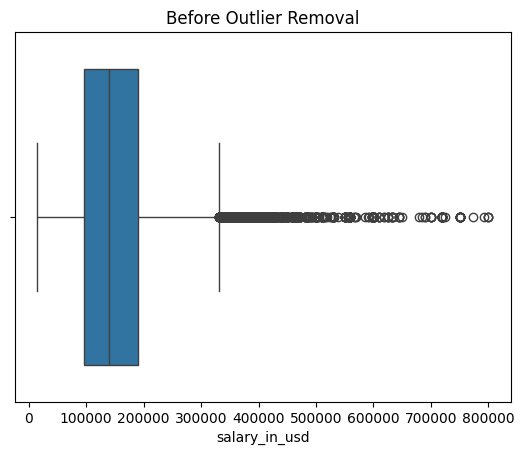

In [25]:
#Salary before filtering 
sns.boxplot(data=df, x='salary_in_usd')
plt.title("Before Outlier Removal")
plt.show()

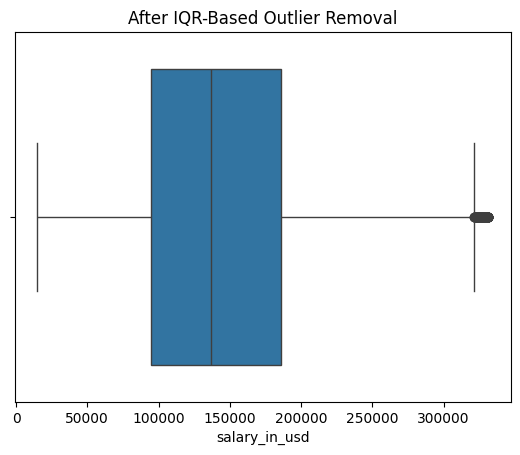

In [26]:
#Remove outliers using IQR
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['salary_in_usd']>= lower) & (df['salary_in_usd'] <= upper)]

sns.boxplot(data=df, x='salary_in_usd')
plt.title("After IQR-Based Outlier Removal")
plt.show()

### Salary Trend Analysis

Text(0, 0.5, 'Salary(USD)')

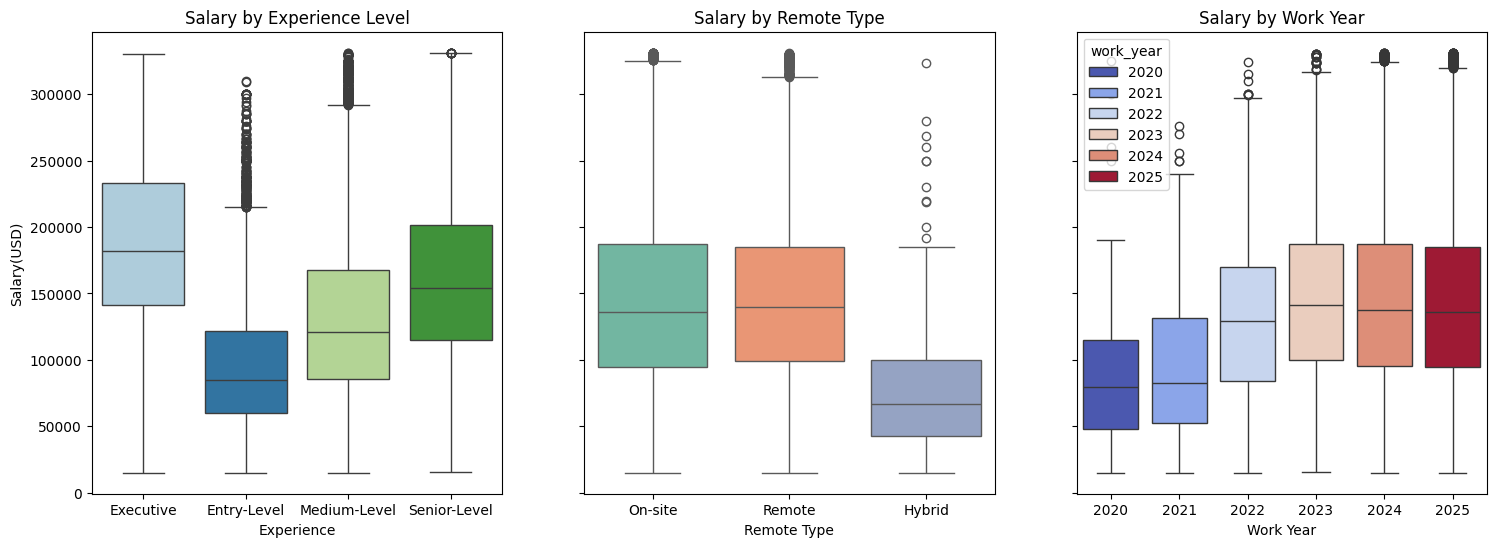

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

#Salary by Experience level
sns.boxplot(data=df, x='experience_level', y='salary_in_usd', hue='experience_level', ax=axes[0], palette='Paired')
axes[0].set_title('Salary by Experience Level')
axes[0].set_xlabel('Experience')
axes[0].set_ylabel('Salary(USD)')

#Salary by remote Type
sns.boxplot(data=df, x='remote_type', y='salary_in_usd', hue='remote_type', ax=axes[1], palette='Set2')
axes[1].set_title('Salary by Remote Type')
axes[1].set_xlabel('Remote Type')
axes[1].set_ylabel('Salary(USD)')

#Salary by Work Year
sns.boxplot(data=df, x='work_year', y='salary_in_usd', hue='work_year', ax=axes[2], palette='coolwarm')
axes[2].set_title('Salary by Work Year')
axes[2].set_xlabel('Work Year')
axes[2].set_ylabel('Salary(USD)')


- There is an upward trend in Salary with experience. Executive professionals earn significantly higher than other level, exceeding $200,000 annually, reflecting their strategic and leadership responsibilities. Apart from experience, factors like Job-role, company-size or location also influencing the Salary. 
- Salary Trend for Remote type is equally divided for the positions that are On-site and remote. But there is slight preference for on-site roles due to perceived productivity benefits. 
- Data Science and AI roles have seen steady salary growth since 2020, driven by digital transformation. 


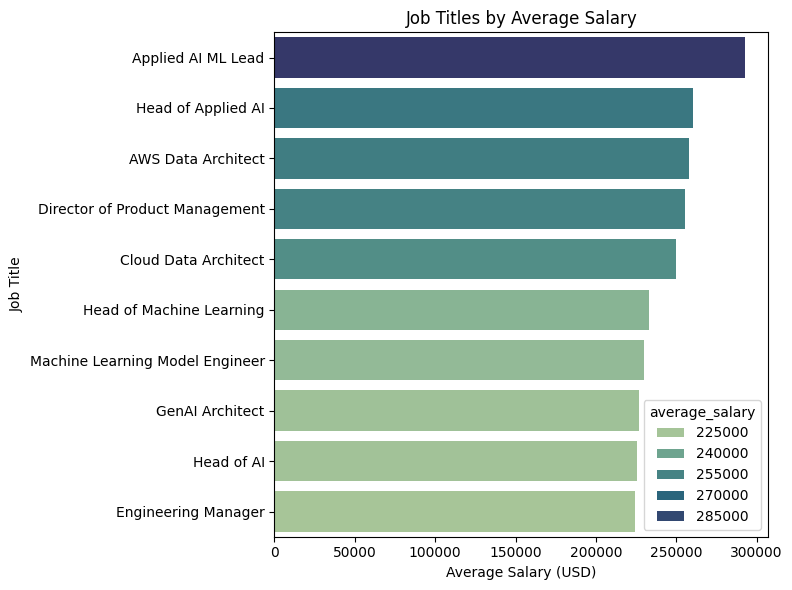

In [28]:
#job title by avg salary

salary_by_job= df.groupby('job_title').agg(  #Calculate Total salary and job count to find salary per job 
    average_salary=('salary_in_usd', 'mean'),
    job_count=('job_title', 'count')
).reset_index().sort_values(by='average_salary', ascending=False)


plt.figure(figsize=(8,6))
sns.barplot(
    x='average_salary', 
    y='job_title',
    hue='average_salary' , 
    data=salary_by_job.head(10), palette="crest"
)
plt.title('Job Titles by Average Salary')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

- Among the common job titles, Applied AI ML Lead and Head of Applied AI command the highest paying average salaries. 
- Architect-level positions(AWS, Cloud, GenAI) dominate the high end of salary distribution.
- Also, Managerial roles like Director of Product Management, Engineering Manager and Head of AI appear among the top earners. 

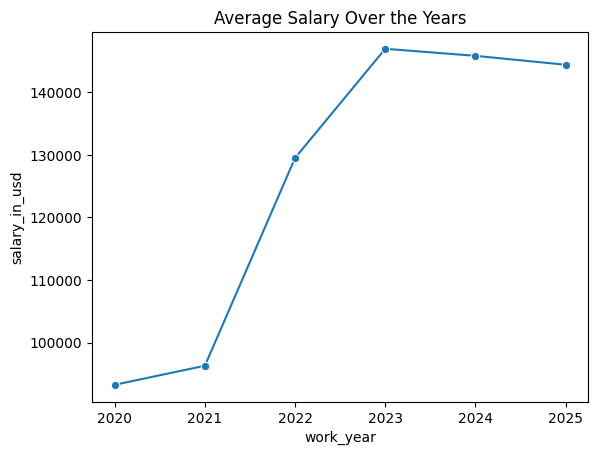

In [29]:
#salary trends over the years 

yearly_trend = df.groupby('work_year')['salary_in_usd'].mean().reset_index()
sns.lineplot(data=yearly_trend, x='work_year', y='salary_in_usd', marker='o')
plt.title('Average Salary Over the Years')
plt.show()

- The earning potential in the fields of Data Science, AI & ML has drastically improved  from 2021 to 2023.
- Slight Pleateau from 2024 indicates market stablization or cost control in hiring.
 

In [30]:
#salary by highest job_count

job_salary = df.groupby('job_title').agg(
    avg_salary_usd=('salary_in_usd', 'mean'),
    job_count=('job_title', 'count')
).sort_values(by='job_count', ascending=False).reset_index()

job_salary.head(10)

,job_title,avg_salary_usd,job_count
0,Data Scientist,148093.189132,6588
1,Data Engineer,142370.860713,6483
2,Data Analyst,103992.023448,5928
3,Software Engineer,168791.344408,4274
4,Engineer,154501.246477,3761
5,Manager,161650.001587,3151
6,Machine Learning Engineer,178308.211955,3095
7,Analyst,112884.532753,2412
8,Analytics Engineer,148475.637353,1194
9,Research Scientist,176203.959863,1171


- Most in demand titles - Data Scientist, Data Engineer, Data Analyst, shows consistent growth from 2020 - 2024 and slightly stabilized in 2025. 

In [31]:
#salary distribution by country
#grouped total salary by company_location(country)
salary_by_country = df.groupby('company_location')['salary_in_usd'].sum().reset_index()
salary_by_country = salary_by_country.sort_values(by='salary_in_usd', ascending=False).head(10)
salary_by_country

,company_location,salary_in_usd
90,United States,8080082991
12,Canada,508665287
89,United Kingdom,231238520
5,Australia,55417729
30,Germany,34366163
59,Netherlands,26477750
29,France,18979524
52,Lithuania,17204541
81,Spain,12327930
41,Ireland,11586990


- United States dominates AI salaries with over $8 billion USD, followed by Canada (~$500 million USD).
- UK, Australia, Germany among leading countries in terms of AI.

### Job trend analysis

In [32]:
#job count by company location 
job_count_by_country = df.groupby(['job_title', 'company_location']).size().reset_index(name='count')
job_count_by_country = job_count_by_country.sort_values(by='count', ascending=False)

job_count_by_country.head(10)

,job_title,company_location,count
849,Data Scientist,United States,5461
613,Data Engineer,United States,5186
514,Data Analyst,United States,4662
1498,Software Engineer,United States,3655
993,Engineer,United States,3271
1211,Manager,United States,2731
1144,Machine Learning Engineer,United States,2523
176,Analyst,United States,2020
1414,Research Scientist,United States,1086
1317,Product Manager,United States,1032


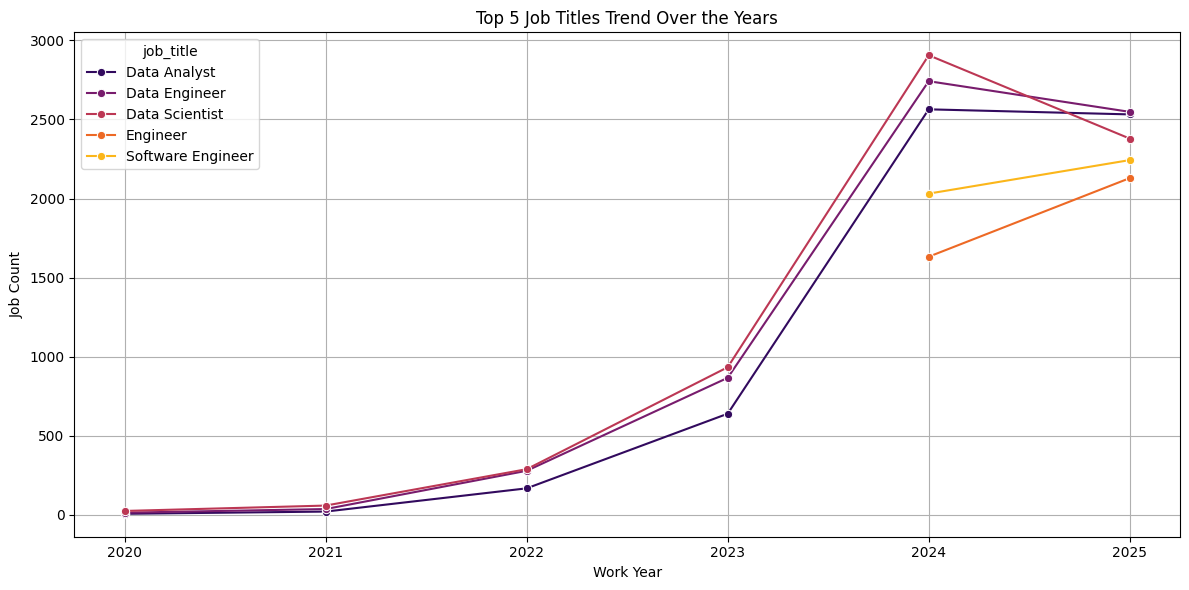

In [33]:
#Top Job Titles by Work Year

top_jobs = df['job_title'].value_counts().head(5).index     #top N titles by count

# Filter original DataFrame to include only top N jobs
filtered_df = df[df['job_title'].isin(top_jobs)]

job_trend = filtered_df.groupby(['job_title', 'work_year']).size().reset_index(name='count') #group by job title and work year

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=job_trend,
    x='work_year',
    y='count',
    hue='job_title',
    marker='o',
    palette='inferno'
)

plt.title('Top 5 Job Titles Trend Over the Years')
plt.xlabel('Work Year')
plt.ylabel('Job Count')
plt.grid(True)
plt.tight_layout()
plt.show()

- Data Scientist and Data Engineer rose rapidly in 2024.
- Demand for Engineer and Software Engineer caught up in 2025. 

In [34]:
#job count based on experience level
job_count_by_experience = df.groupby(['job_title', 'experience_level']).size().reset_index(name='count') 
job_count_by_experience = job_count_by_experience.sort_values(by='count', ascending=False)

job_count_by_experience

,job_title,experience_level,count
440,Data Scientist,Senior-Level,3587
305,Data Engineer,Senior-Level,3550
800,Software Engineer,Senior-Level,2531
257,Data Analyst,Entry-Level,2337
260,Data Analyst,Senior-Level,2332
...,...,...,...
10,AI Developer,Executive,1
5,AI Data Engineer,Senior-Level,1
17,AI Engineering Lead,Senior-Level,1
4,AI Data Engineer,Entry-Level,1


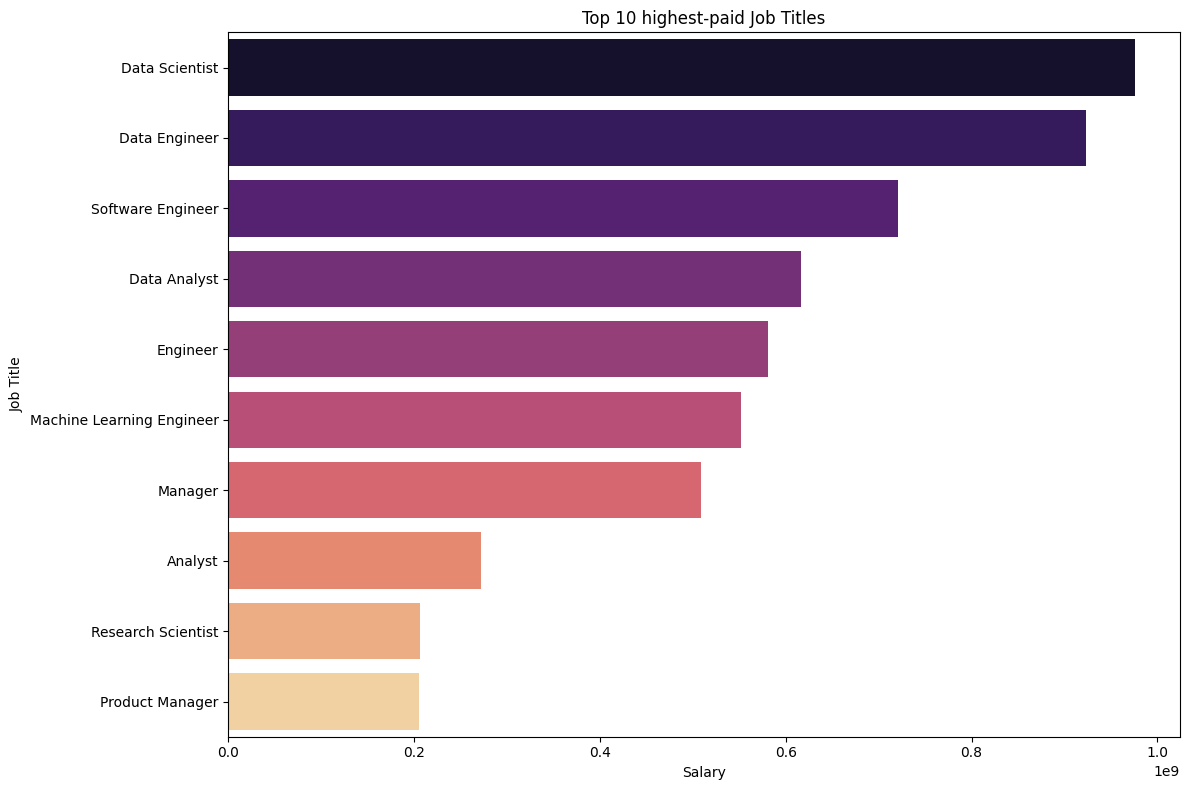

In [35]:
#top titles by Salary 
top_titles_by_salary = df.groupby('job_title', as_index=False)['salary_in_usd'].sum()
top_titles_by_salary = top_titles_by_salary.sort_values(by='salary_in_usd', ascending=False).head(10)

plt.figure(figsize=(12,8))
sns.barplot(
    y='job_title',
    x='salary_in_usd',
    data=top_titles_by_salary.head(10),
    palette="magma",
    hue='job_title',
    legend=False
)
plt.title('Top 10 highest-paid Job Titles')
plt.xlabel('Salary')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()


- Data Scientist, Data Engineer and Software Engineer are leading roles in terms of payout, due to high job volume and salary. 


### Workforce Trends Over Time

<Figure size 1000x600 with 0 Axes>

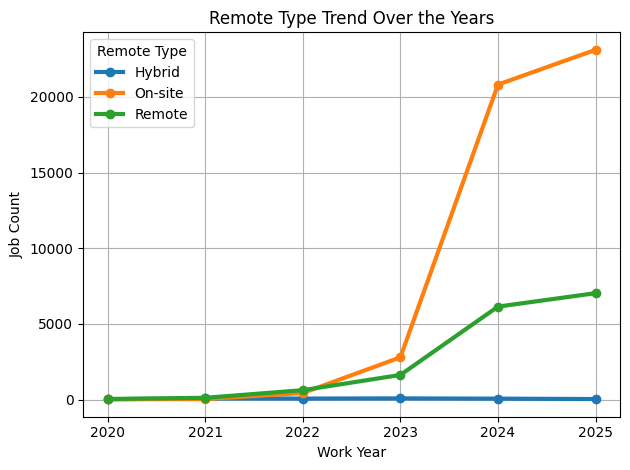

In [36]:
#remote ratio trends over time 

#group and job_count by year
work_year_by_remote_type = df.groupby(['work_year','remote_type']).size().reset_index(name='count')

#sorting the values by remote_type 
work_year_by_remote_type = work_year_by_remote_type.sort_values(by='remote_type', ascending=False)

remote_trend = df.groupby(['work_year', 'remote_type']).size().unstack(fill_value=0) #group dataset by work year and remote type by filling missing values
remote_trend = remote_trend.sort_index() #sort the table by work_year

plt.figure(figsize=(10,6))
remote_trend.plot(marker='o', linewidth=3)

plt.title('Remote Type Trend Over the Years')
plt.xlabel('Work Year')
plt.ylabel('Job Count')
plt.legend(title='Remote Type')
plt.grid(True)
plt.tight_layout()
plt.show()

- The face of Remote type trend have has majorly influenced after COVID, showing increase in remote positions after 2022. Within a year, trend has shifted more towards On-site working conditions by companies, to improve productivity and efficiency in the work. 

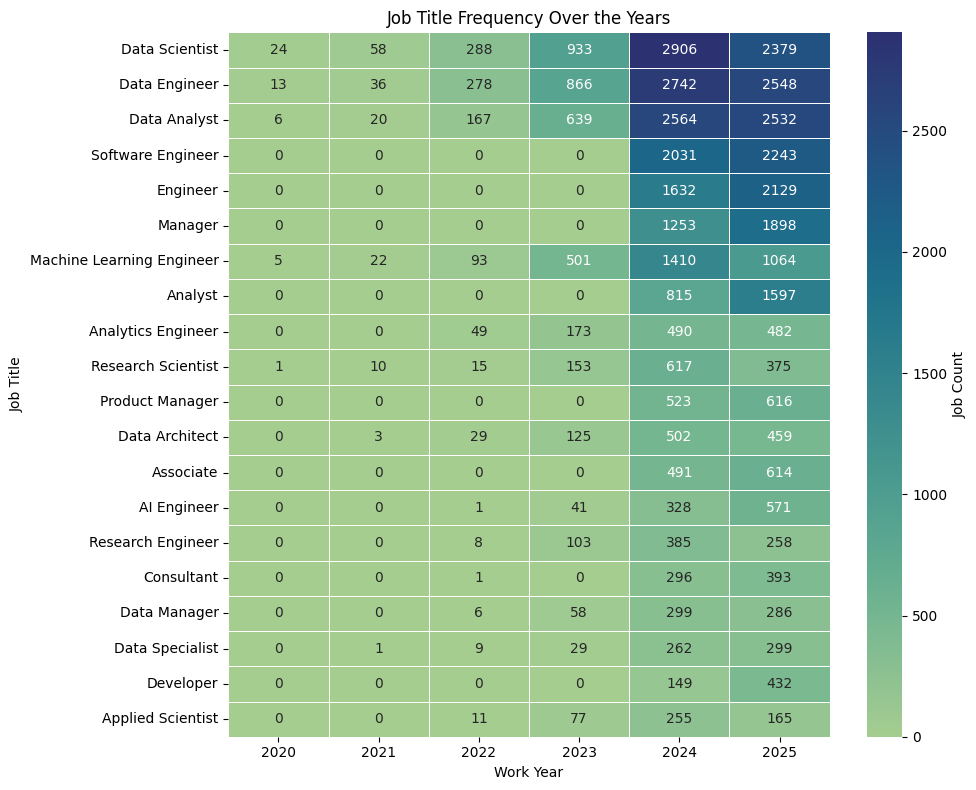

In [37]:
#job title frequency over the years 

#group and count job titles by year
job_count_by_year = df.groupby(['job_title','work_year']).size().reset_index(name='count')

#get top 20 job titles
top_titles = df['job_title'].value_counts().head(20).index.tolist()

filtered_titles = job_count_by_year[job_count_by_year['job_title'].isin(top_titles)]

# Pivot data for heatmap
heatmap_data = filtered_titles.pivot(index='job_title', columns='work_year', values='count').fillna(0)

# Sort job titles by total count for better heatmap ordering
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10,8))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".0f", linewidths=.5,
     cmap="crest",
    cbar_kws={'label' : 'Job Count'}
    )
plt.title('Job Title Frequency Over the Years')
plt.xlabel('Work Year')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

- As per the job counts, it is depicted that demand for Data Science, AI and ML related positions has been more than doubled after 2023, showing steep increase in the counts for almost all the positions. AMong which, Data Scientist is at the highest in terms of job offers.

### Job Market Landscape & Demand


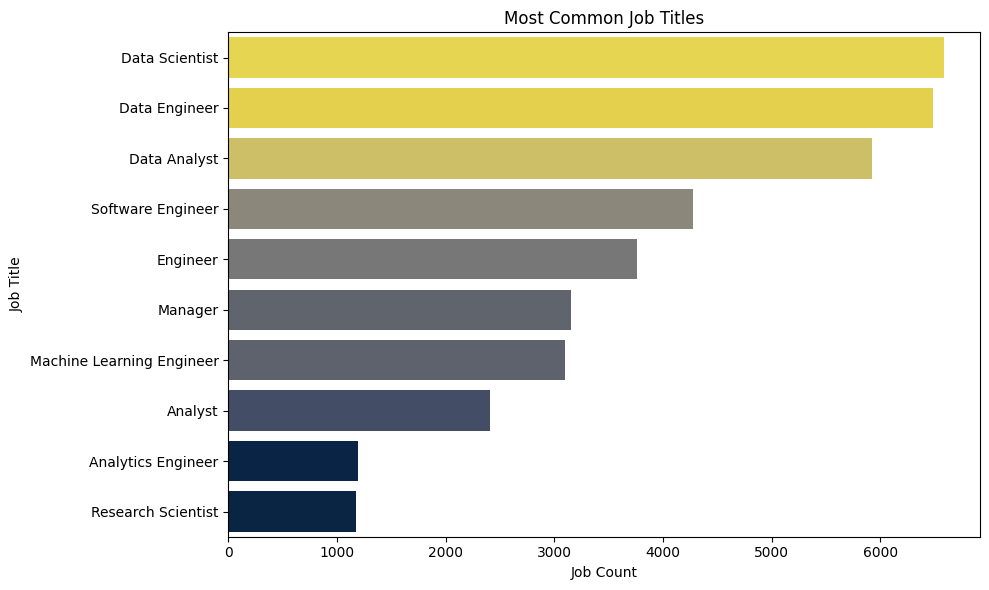

In [38]:
#grouped job count by average salary
job_salary = df.groupby('job_title').agg(
    avg_salary_usd=('salary_in_usd', 'mean'),
    job_count=('job_title', 'count')
).sort_values(by='job_count', ascending=False).reset_index()

#visualizing top 10 job titles by count 
top_jobs_by_count = job_salary.head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x='job_count',
    y='job_title',
    hue='job_count',
    data=job_salary.head(10),
    palette="cividis",
    legend=False
)
plt.title('Most Common Job Titles')
plt.xlabel('Job Count')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()


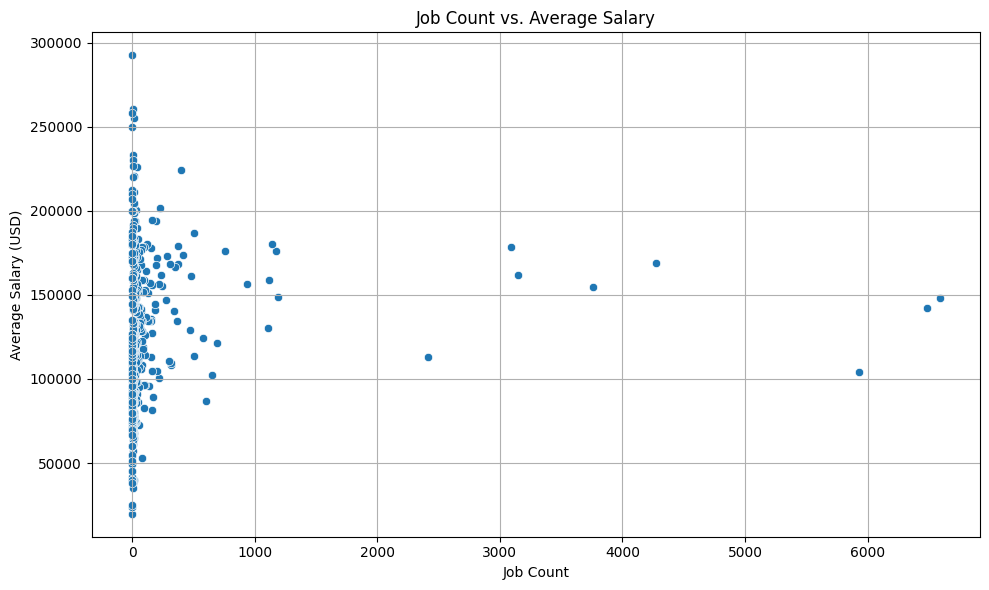

In [39]:
#Job count vs average salary 

plt.figure(figsize=(10, 6))
sns.scatterplot(data=job_salary, x='job_count', y='avg_salary_usd')
plt.title('Job Count vs. Average Salary')
plt.xlabel('Job Count')
plt.ylabel('Average Salary (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

- High Salaries are mostly for low-frequency job-titles. 
- Mass hiring roles like Data Analyst and Data Engineer have comparatively lower average salaries contrary to higher job availbility.

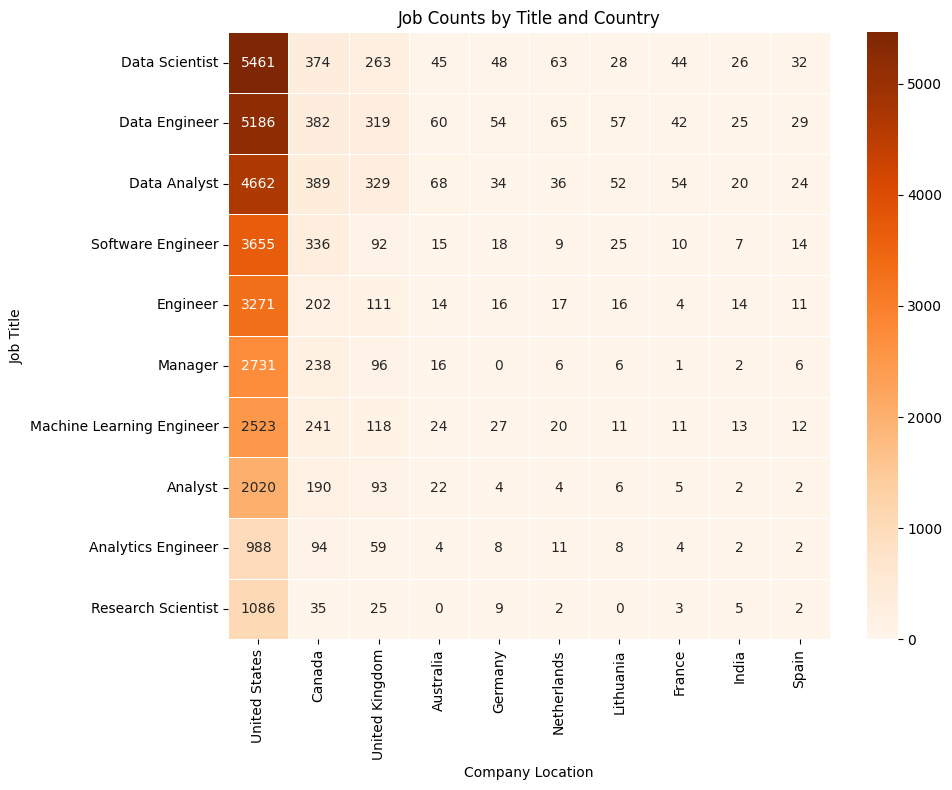

In [40]:
#job counts by title and country 

#grouoped job count by company location and sorted as per job count
job_count_by_country = df.groupby(['job_title', 'company_location']).size().reset_index(name='count')
job_count_by_country = job_count_by_country.sort_values(by='count', ascending=False)

#pivot data by job_title, company location and job count 
heatmap_country = job_count_by_country.pivot(index='job_title', columns='company_location', values='count').fillna(0) 

#visualized top 10 job titles by country 
top_jobs = df['job_title'].value_counts().head(10).index.tolist()
top_countries = df['company_location'].value_counts().head(10).index.tolist()

#filtered heatmap to top jobs and countries
heatmap_filtered = heatmap_country.loc[top_jobs, top_countries]

plt.figure(figsize=(10,8))
sns.heatmap(
    heatmap_filtered,
    annot=True, fmt=".0f", linewidths=.5,
     cmap="Oranges"
    )
plt.title('Job Counts by Title and Country')
plt.xlabel('Company Location')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

- United States dominates globally in terms of job availability in field of AI, offering highest job across all roles, followed by Canada, UK and Germany especially for Data-related roles. 
- India and Spain are still in emerging markets, though comparatively lower in volume. 

### Compensation Trends By Role & Experience

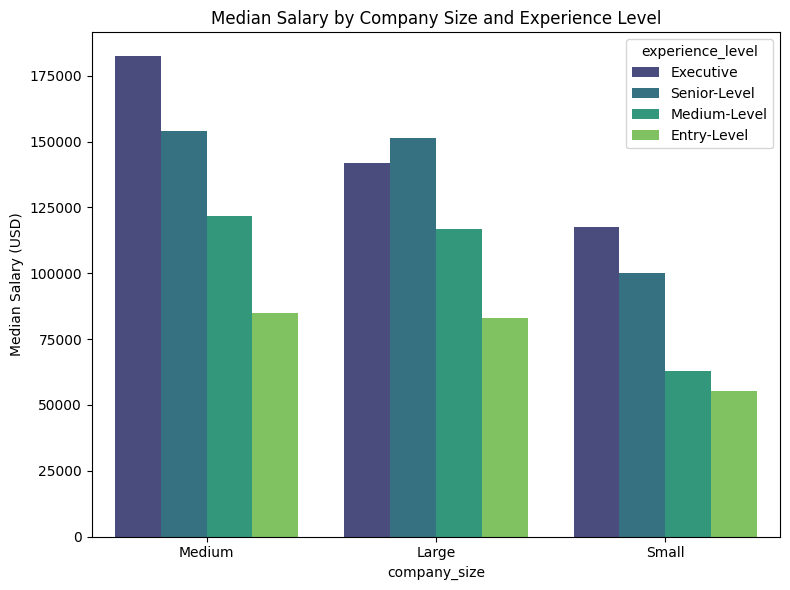

In [41]:
#salary by company_size and experience level
company_salary = df.groupby(['company_size', 'experience_level'])['salary_in_usd'].median().reset_index()       #group company size and experience level by average salary
company_salary = company_salary.sort_values(by='salary_in_usd', ascending=False)    #sorted values by salary 

company_salary

plt.figure(figsize=(8,6))
sns.barplot(
    x='company_size',
    y='salary_in_usd',
    hue='experience_level',
    data=company_salary,
    palette='viridis'
)
plt.title('Median Salary by Company Size and Experience Level')
plt.xlabel('company_size')
plt.ylabel('Median Salary (USD)')
plt.tight_layout()
plt.show()

- Medium Sized companies offer highest Executive salaries ($180K), while Large companies pay better at Senior Level ($150K) depicts stability and growth. 
- Small Companies pay least across all the levels. 

### Company Size and Compensation Structure

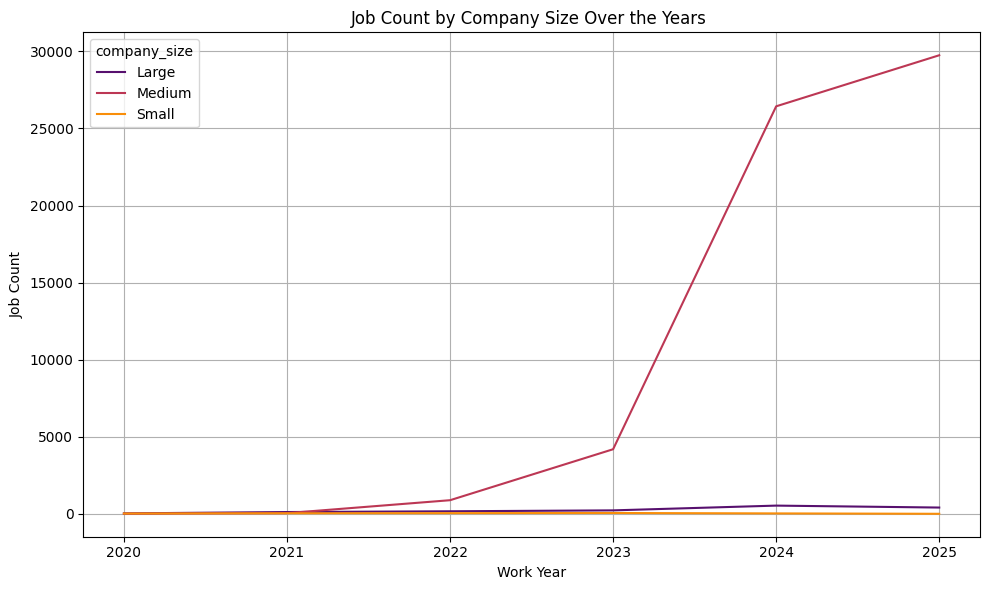

In [42]:
#job_count by company size over the years 
job_count_by_size_year = df.groupby(['work_year', 'company_size']).size().reset_index(name='job_count') 
pivot_data = job_count_by_size_year.pivot(index='work_year', columns='company_size', values='job_count').fillna(0) #pivot table for company size by work year and job count 

plt.figure(figsize=(10,6))
sns.lineplot(
    data=job_count_by_size_year,
    x='work_year',
    y='job_count',
    hue='company_size',
    markers='o',
    palette='inferno'
)

plt.title('Job Count by Company Size Over the Years ')
plt.xlabel('Work Year')
plt.ylabel('Job Count')
plt.grid(True)
plt.tight_layout()
plt.show()

- Medium sized companies shows rise in hiring after 2023, while large companies shows steady trend and small companies show little contribution. 

### Remote Work Trends & Salary Analysis

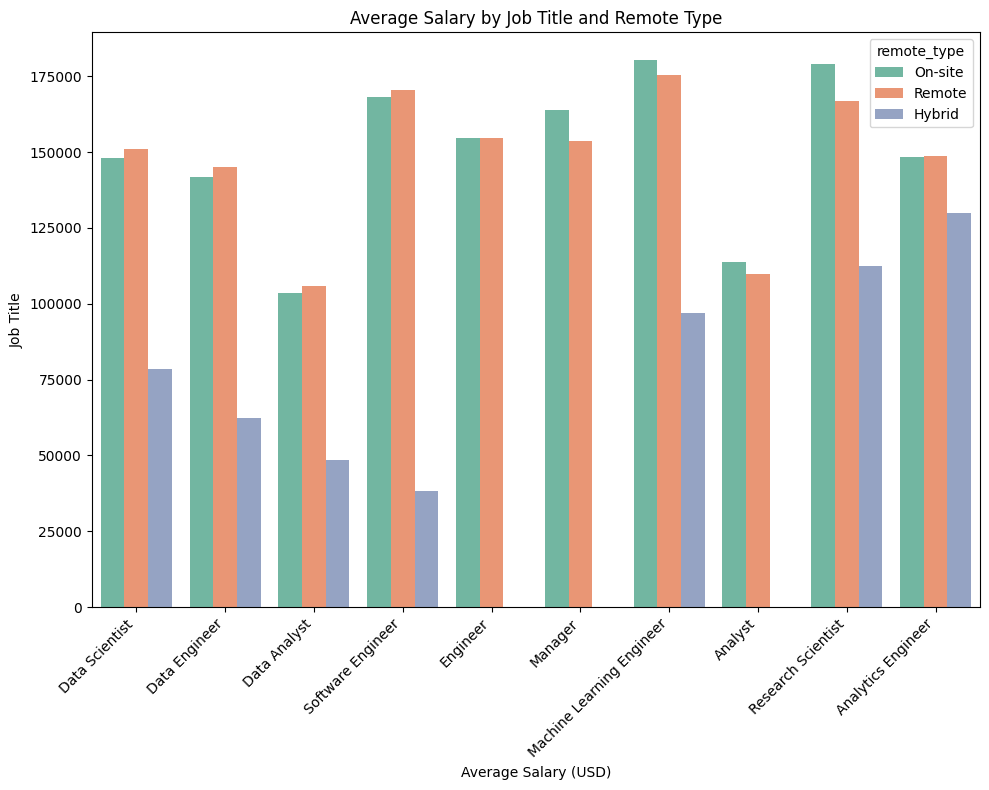

In [43]:
#remote trend by salary and job_title

#grouped job count and remote type by average salary
job_remote_salary = df.groupby(['job_title', 'remote_type']).agg(
    job_counts=('salary_in_usd', 'count'),
    avg_salary=('salary_in_usd', 'mean')
).reset_index()

#visualized remote type of top 10 titles by average salary
top_job_titles=df['job_title'].value_counts().head(10).index.tolist()   #Get top 10 titles 
job_remote_salary_top = job_remote_salary[job_remote_salary['job_title'].isin(top_job_titles)] #filter job_remote_salary for those top titles

job_remote_salary_top = job_remote_salary_top.sort_values(by='job_counts', ascending=False) #sort by job count

plt.figure(figsize=(10,8))
sns.barplot(
    x='job_title',
    y='avg_salary',
    hue='remote_type',
    data=job_remote_salary_top,
    palette='Set2'
)
plt.title('Average Salary by Job Title and Remote Type')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Job Title')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Higher paying roles like Data Scientist, Data Engineer and Data Analyst are offered as remote jobs.
- Hybrid roles show lowest salaries, suggesting limited incentives.

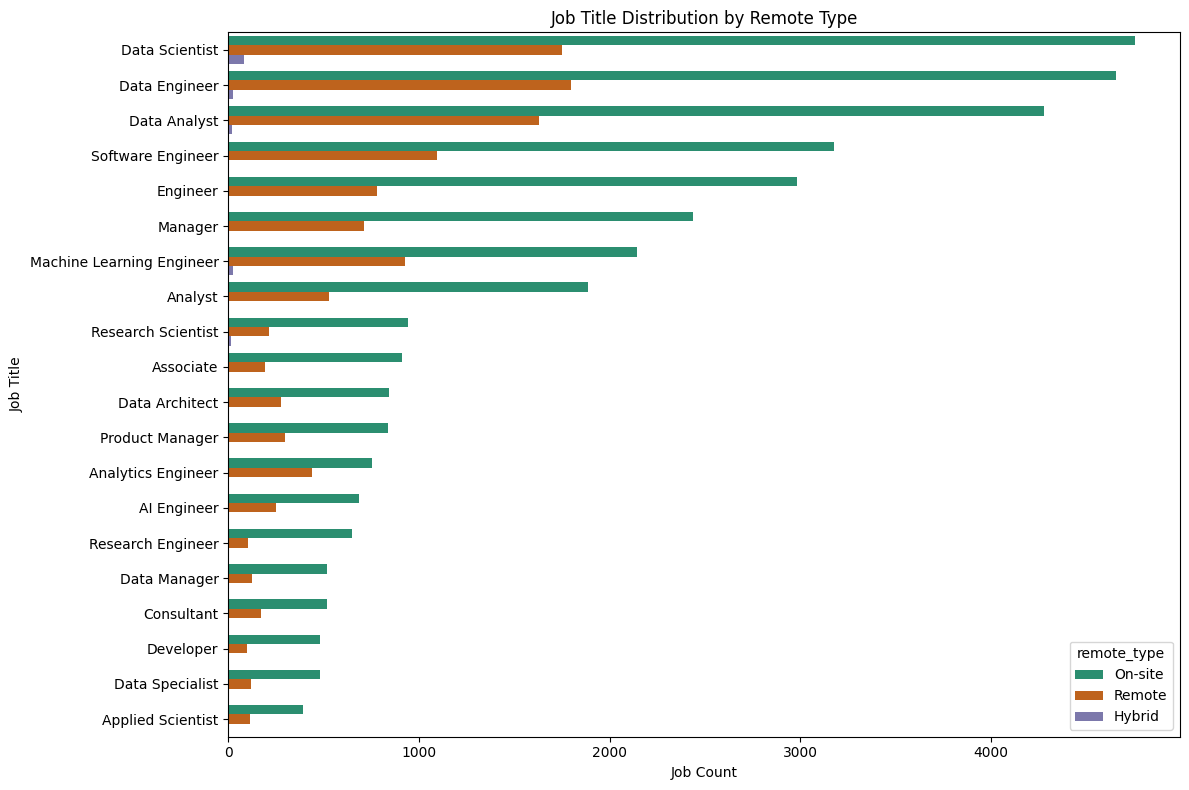

In [44]:
#job-title by remote-type distribution 
job_count_by_remote_type = df.groupby(['job_title', 'remote_type']).size().reset_index(name='count')
job_count_by_remote_type = job_count_by_remote_type.sort_values(by='count', ascending=False)
job_count_by_remote_type

plt.figure(figsize=(12,8))
sns.barplot(
    x='count', y='job_title', hue='remote_type',
    data=job_count_by_remote_type[job_count_by_remote_type['job_title'].isin(top_titles)],
    palette = 'Dark2'
)
plt.title('Job Title Distribution by Remote Type')
plt.xlabel('Job Count')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

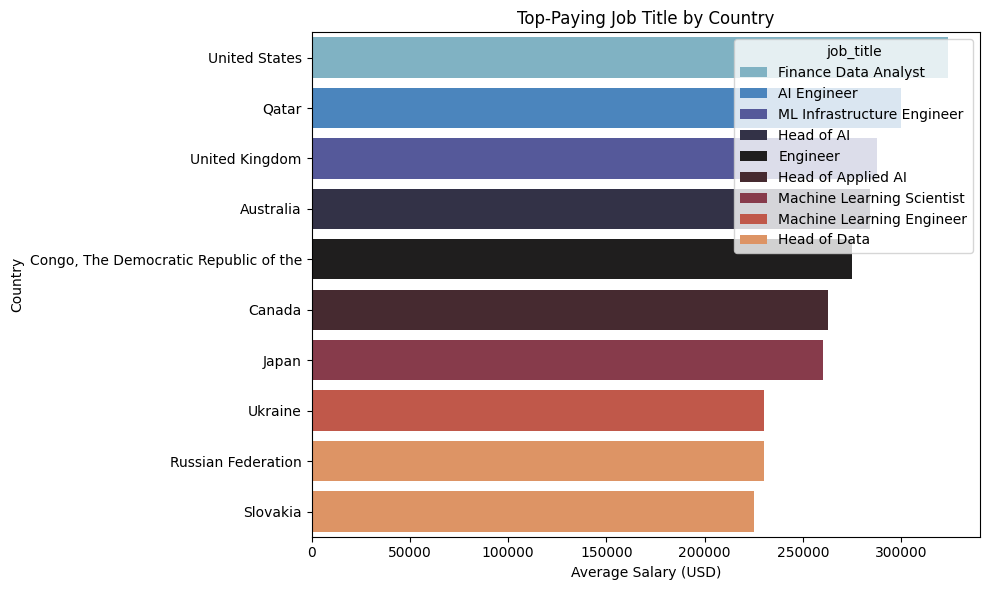

In [45]:
#-top paying job-title by country
#grouped by country_location and job_title and calculated avg salary
country_job_salary = df.groupby(['company_location', 'job_title'])['salary_in_usd'].mean().reset_index()

#sort data by country name (ascending) and within each country sort salary (descending), and keeping first 
top_job_by_country = country_job_salary.sort_values(['company_location', 'salary_in_usd'], ascending=[True, False])\
            .drop_duplicates(subset=['company_location'])

top_job_by_country = top_job_by_country.sort_values(by='salary_in_usd', ascending=False) 
top_job_by_country

plt.figure(figsize=(10,6))
sns.barplot(
    x='salary_in_usd',
    y='company_location',
    hue='job_title',
    data=top_job_by_country.head(10),
    palette='icefire'
)

plt.title('Top-Paying Job Title by Country')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

- US leads with Finance Data Analyst as top-paid title (~$310K).
- While Qatar (AI Engineer), UK (ML Insfrastructure Engineer), Australia (Head OF AI) among top-paid roles globally. 

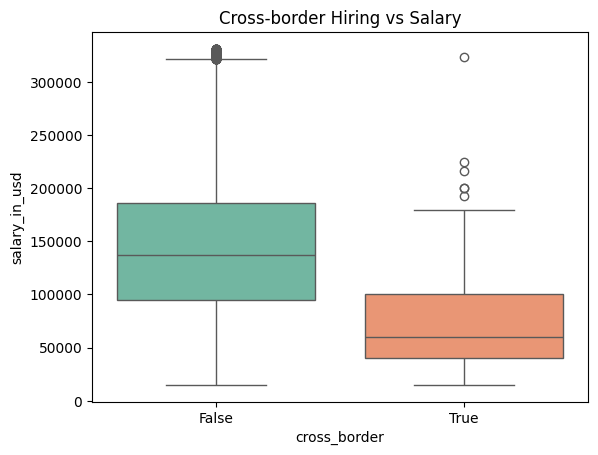

In [46]:
#cross border hiring 
df['cross_border'] = df['employee_residence'] != df['company_location']
sns.boxplot(x="cross_border", y="salary_in_usd", hue="cross_border", data=df, palette="Set2", legend=False)
plt.title("Cross-border Hiring vs Salary")
plt.show()

- Distribution of salary for hiring within country is more (~$310K) while that of cross borders range below $210K. Likely impacted by factors like currency conversion rates or tax implications. 

### Correlation Matrix

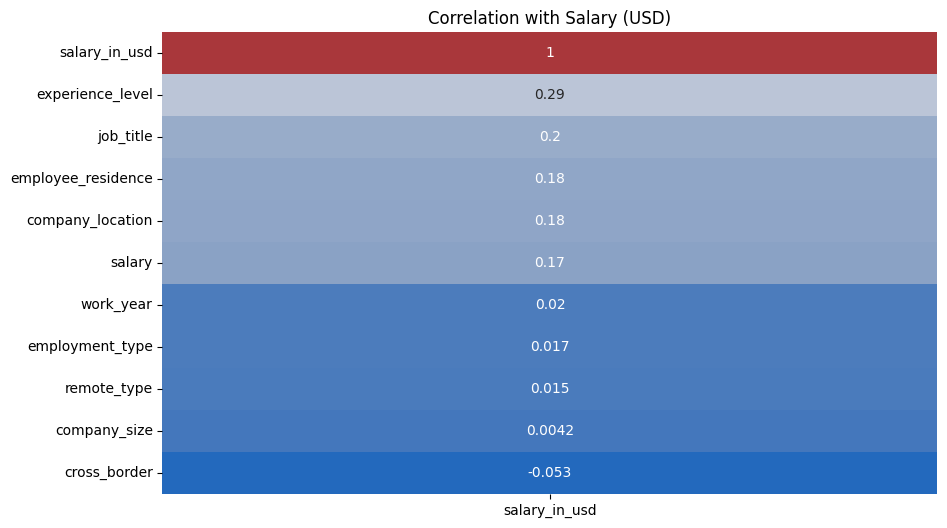

In [47]:
df_encoded = df.copy()

# Encode categorical columns using pandas
categorical_cols = ['experience_level', 'employment_type', 'job_title', 
                    'company_size', 'employee_residence', 'company_location', 'remote_type']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Compute correlation with salary
corr = df_encoded.corr(numeric_only=True)

# Plot only correlation with salary_in_usd
plt.figure(figsize=(10, 6))
sns.heatmap(corr[['salary_in_usd']].sort_values(by='salary_in_usd', ascending=False),
            annot=True, cmap='vlag', cbar=False)
plt.title('Correlation with Salary (USD)')
plt.show()

- Experience Level(0.29) shows higher the experience, clearly leads to higher salaries. 
- Employee residence(0.24) and Job title (0.2) are also highly affected by salary showing certain roles are paid more in some countries.   
- Company location (0.18) moderately related to salary, showing high-paying regions offering better compensation. 
- Work year(0.02) indicating salary not likely increasing over the years.
- Employment type, Company size AND remote-type shows low correlation to salary, not much influencing by salary, while cross border hiring shows negatively influenced by salary. 

## **Project Summary**

#### **Goal** - Analyze Job salary trends in data-related roles across experience level, location and work-type.
##### **Tool Used** - Python (Pandas, Matplotlib, Seaborn), Jupyter Notebook, Power BI.
##### **Key Insights**:
~ **Leadership & Specialized Roles Pay Most** : Specialized and leadership AI roles offer highest compensation, showing increasing salary with experience. Executive roles earning highest over $200K on average.

~ **Location Matters** : US Based companies pays significantly more for AI/ML roles, followed by Canada and Europe.

~ **Data-Centric Roles Dominate**: In terms of job demand, Data Centric roles like Data Science, Engineering and Analysis dominate overall market in volume. 

~ **Company Size Trends** : Medium-sized companies shows biggest drivers of AI/Data hiring. 

~ **Work Setup & Pay**: AI/ML realted jobs peaked post COVID for remote work-type, but on-site hiring is now leading, possibly for productivity. Hybrid work pays less and has lowest adoption. 

~ **High Salaries, High Volume**: High paying jobs are low in volume; high-volume roles pay moderately. 

~ **Cross-border hiring is Limited**: Hiring Within borders is preferred due to:
    - local regulations, payroll ease or in-office expectations. 
    - avoid barriers such as time zones, communications or legal hurdles.


In [48]:
df.to_csv('cleaned_job_salaries.csv', index=False)